In [1]:
import numpy as np
import matplotlib.pyplot as plt

from hp_core import (
    lyapunov_spectrum_blocks,
    spectrum_statistics,
    z_maxima
)

In [2]:
# HP parameters that stay fixed

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

initial_state = np.array([
    1.0,
    1.0,
    1.0
])

dt = 0.01

In [3]:
# Fine scan around d1 = 0.40

d1_scan_040 = np.arange(
    0.3900,
    0.4100 + 0.00025,
    0.0005
)

d1_scan_040 = np.round(d1_scan_040, 4)

print("Number of d1 values:", len(d1_scan_040))

Number of d1 values: 41


In [4]:
scan_results_040 = []
scan_maxima_040 = []

In [5]:
for i, d1_value in enumerate(d1_scan_040):

    parameters = np.array([
        a1,
        a2,
        b1,
        b2,
        d1_value,
        d2
    ])


    # Lyapunov spectrum

    block_exponents, final_state, _ = lyapunov_spectrum_blocks(
        parameters,
        initial_state,
        dt,
        transient_time=20000.0,
        alignment_time=5000.0,
        average_time=20000.0,
        renormalization_time=1.0,
        block_time=500.0
    )

    (
        spectrum,
        errors,
        _,
        _,
        _,
        stationary
    ) = spectrum_statistics(block_exponents)


    # Successive maxima of z

    maxima, _ = z_maxima(
        parameters,
        initial_state,
        dt,
        transient_time=20000.0,
        record_time=20000.0,
        max_peaks=500
    )

    distinct_maxima = len(
        np.unique(
            np.round(maxima, 3)
        )
    )


    scan_results_040.append([
        d1_value,
        spectrum[0],
        errors[0],
        spectrum[1],
        errors[1],
        spectrum[2],
        errors[2],
        distinct_maxima,
        stationary[0],
        stationary[1],
        stationary[2],
        final_state[0],
        final_state[1],
        final_state[2]
    ])


    for z_peak in maxima:

        scan_maxima_040.append([
            d1_value,
            z_peak
        ])


    print(
        f"[{i + 1:02d}/{len(d1_scan_040)}] "
        f"d1 = {d1_value:.4f}   "
        f"lambda1 = {spectrum[0]:.6f}   "
        f"lambda2 = {spectrum[1]:.6f}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[01/41] d1 = 0.3900   lambda1 = 0.008234   lambda2 = -0.000025   distinct maxima = 322
[02/41] d1 = 0.3905   lambda1 = 0.007950   lambda2 = -0.000029   distinct maxima = 336
[03/41] d1 = 0.3910   lambda1 = 0.006383   lambda2 = 0.000001   distinct maxima = 295
[04/41] d1 = 0.3915   lambda1 = -0.000004   lambda2 = -0.000436   distinct maxima = 6
[05/41] d1 = 0.3920   lambda1 = 0.007795   lambda2 = 0.000096   distinct maxima = 313
[06/41] d1 = 0.3925   lambda1 = 0.008095   lambda2 = 0.000102   distinct maxima = 354
[07/41] d1 = 0.3930   lambda1 = 0.008540   lambda2 = 0.000032   distinct maxima = 354
[08/41] d1 = 0.3935   lambda1 = 0.007821   lambda2 = -0.000036   distinct maxima = 318
[09/41] d1 = 0.3940   lambda1 = 0.008275   lambda2 = -0.000012   distinct maxima = 351
[10/41] d1 = 0.3945   lambda1 = 0.008343   lambda2 = 0.000091   distinct maxima = 336
[11/41] d1 = 0.3950   lambda1 = 0.007859   lambda2 = 0.000007   distinct maxima = 327
[12/41] d1 = 0.3955   lambda1 = 0.007377   lambda2

In [6]:
scan_results_040 = np.array(
    scan_results_040,
    dtype=float
)

scan_maxima_040 = np.array(
    scan_maxima_040,
    dtype=float
)

print(scan_results_040.shape)
print(scan_maxima_040.shape)

(41, 14)
(17475, 2)


In [7]:
scan_header_040 = """Fine Hastings-Powell scan around d1 = 0.40
d1 range = 0.3900 to 0.4100
d1 step = 0.0005

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 20000
renormalization_time = 1
block_time = 500
initial_state = [1.0, 1.0, 1.0]

errors = half-width of approximate 95% Student interval

columns:
d1,lambda1,error1,lambda2,error2,lambda3,error3,distinct_maxima,
stationary1,stationary2,stationary3,final_x,final_y,final_z
"""

np.savetxt(
    "data/hp_d1_scan_039_041.csv",
    scan_results_040,
    delimiter=",",
    header=scan_header_040,
    comments="# "
)

print("Saved: data/hp_d1_scan_039_041.csv")

Saved: data/hp_d1_scan_039_041.csv


In [8]:
maxima_header_040 = """Successive maxima of z for the fine d1 scan around d1 = 0.40
d1 range = 0.3900 to 0.4100
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000
initial_state = [1.0, 1.0, 1.0]

columns: d1,z_max
"""

np.savetxt(
    "data/hp_d1_scan_039_041_maxima.csv",
    scan_maxima_040,
    delimiter=",",
    header=maxima_header_040,
    comments="# "
)

print("Saved: data/hp_d1_scan_039_041_maxima.csv")

Saved: data/hp_d1_scan_039_041_maxima.csv


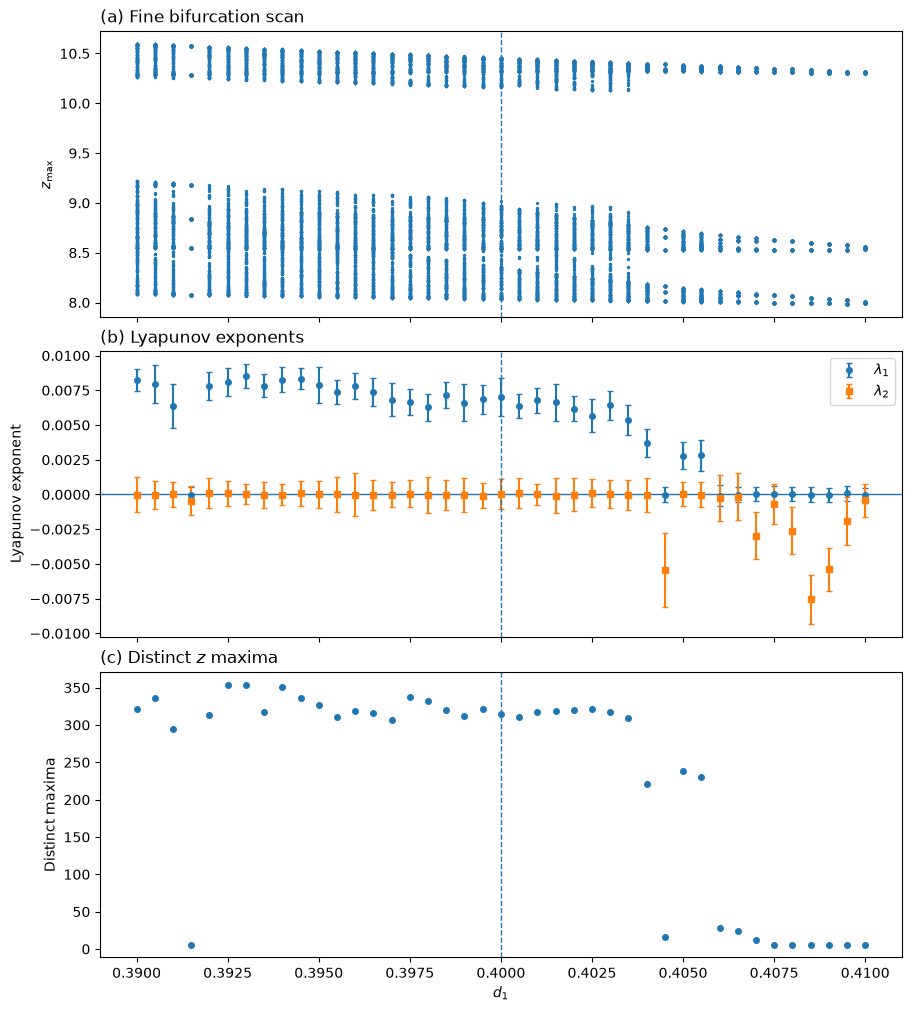

In [9]:
d1_values_040 = scan_results_040[:, 0]

lambda1_040 = scan_results_040[:, 1]
error1_040 = scan_results_040[:, 2]

lambda2_040 = scan_results_040[:, 3]
error2_040 = scan_results_040[:, 4]

distinct_040 = scan_results_040[:, 7]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True,
    constrained_layout=True
)


# (a) Bifurcation diagram

axes[0].scatter(
    scan_maxima_040[:, 0],
    scan_maxima_040[:, 1],
    s=2
)

axes[0].axvline(
    0.40,
    linestyle="--",
    linewidth=1
)

axes[0].set_ylabel(
    r"$z_{\max}$"
)

axes[0].set_title(
    "(a) Fine bifurcation scan",
    loc="left"
)


# (b) First and second Lyapunov exponents

axes[1].errorbar(
    d1_values_040,
    lambda1_040,
    yerr=error1_040,
    fmt="o",
    markersize=4,
    capsize=2,
    label=r"$\lambda_1$"
)

axes[1].errorbar(
    d1_values_040,
    lambda2_040,
    yerr=error2_040,
    fmt="s",
    markersize=4,
    capsize=2,
    label=r"$\lambda_2$"
)

axes[1].axhline(
    0.0,
    linewidth=1
)

axes[1].axvline(
    0.40,
    linestyle="--",
    linewidth=1
)

axes[1].set_ylabel(
    "Lyapunov exponent"
)

axes[1].set_title(
    "(b) Lyapunov exponents",
    loc="left"
)

axes[1].legend()


# (c) Number of distinct maxima

axes[2].plot(
    d1_values_040,
    distinct_040,
    "o",
    markersize=4
)

axes[2].axvline(
    0.40,
    linestyle="--",
    linewidth=1
)

axes[2].set_xlabel(
    r"$d_1$"
)

axes[2].set_ylabel(
    "Distinct maxima"
)

axes[2].set_title(
    r"(c) Distinct $z$ maxima",
    loc="left"
)


fig.savefig(
    "figures/hp_d1_scan_039_041.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_scan_039_041.pdf",
    bbox_inches="tight"
)

plt.show()

In [10]:
# Fine scan around the second working point

d1_scan_038 = np.arange(
    0.3750,
    0.3850 + 0.00025,
    0.0005
)

d1_scan_038 = np.round(
    d1_scan_038,
    4
)

print("Number of d1 values:")
print(len(d1_scan_038))

Number of d1 values:
21


In [11]:
scan_results_038 = []
scan_maxima_038 = []

In [12]:
for i, d1_value in enumerate(d1_scan_038):

    parameters = np.array([
        a1,
        a2,
        b1,
        b2,
        d1_value,
        d2
    ])


    # Lyapunov spectrum

    block_exponents, final_state, _ = lyapunov_spectrum_blocks(
        parameters,
        initial_state,
        dt,
        transient_time=20000.0,
        alignment_time=5000.0,
        average_time=20000.0,
        renormalization_time=1.0,
        block_time=500.0
    )

    (
        spectrum,
        errors,
        _,
        _,
        _,
        stationary
    ) = spectrum_statistics(block_exponents)


    # Successive maxima of z

    maxima, _ = z_maxima(
        parameters,
        initial_state,
        dt,
        transient_time=20000.0,
        record_time=20000.0,
        max_peaks=500
    )

    distinct_maxima = len(
        np.unique(
            np.round(maxima, 3)
        )
    )


    scan_results_038.append([
        d1_value,
        spectrum[0],
        errors[0],
        spectrum[1],
        errors[1],
        spectrum[2],
        errors[2],
        distinct_maxima,
        stationary[0],
        stationary[1],
        stationary[2],
        final_state[0],
        final_state[1],
        final_state[2]
    ])


    for z_peak in maxima:

        scan_maxima_038.append([
            d1_value,
            z_peak
        ])


    print(
        f"[{i + 1:02d}/{len(d1_scan_038)}] "
        f"d1 = {d1_value:.4f}   "
        f"lambda1 = {spectrum[0]:.6f}   "
        f"lambda2 = {spectrum[1]:.6f}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[01/21] d1 = 0.3750   lambda1 = 0.010835   lambda2 = 0.000201   distinct maxima = 397
[02/21] d1 = 0.3755   lambda1 = 0.010530   lambda2 = 0.000048   distinct maxima = 346
[03/21] d1 = 0.3760   lambda1 = 0.010021   lambda2 = -0.000102   distinct maxima = 353
[04/21] d1 = 0.3765   lambda1 = 0.010267   lambda2 = 0.000220   distinct maxima = 364
[05/21] d1 = 0.3770   lambda1 = 0.010439   lambda2 = 0.000003   distinct maxima = 385
[06/21] d1 = 0.3775   lambda1 = 0.010040   lambda2 = -0.000037   distinct maxima = 368
[07/21] d1 = 0.3780   lambda1 = 0.010692   lambda2 = -0.000122   distinct maxima = 388
[08/21] d1 = 0.3785   lambda1 = 0.010090   lambda2 = -0.000065   distinct maxima = 379
[09/21] d1 = 0.3790   lambda1 = 0.010345   lambda2 = -0.000013   distinct maxima = 372
[10/21] d1 = 0.3795   lambda1 = 0.010917   lambda2 = -0.000029   distinct maxima = 368
[11/21] d1 = 0.3800   lambda1 = 0.010188   lambda2 = 0.000047   distinct maxima = 350
[12/21] d1 = 0.3805   lambda1 = 0.010886   lambd

In [13]:
scan_results_038 = np.array(
    scan_results_038,
    dtype=float
)

scan_maxima_038 = np.array(
    scan_maxima_038,
    dtype=float
)

print(scan_results_038.shape)
print(scan_maxima_038.shape)

(21, 14)
(9374, 2)


In [14]:
scan_header_038 = """Fine Hastings-Powell scan around d1 = 0.38
d1 range = 0.3750 to 0.3850
d1 step = 0.0005

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 20000
renormalization_time = 1
block_time = 500
initial_state = [1.0, 1.0, 1.0]

errors = half-width of approximate 95% Student interval

columns:
d1,lambda1,error1,lambda2,error2,lambda3,error3,distinct_maxima,
stationary1,stationary2,stationary3,final_x,final_y,final_z
"""

np.savetxt(
    "data/hp_d1_scan_0375_0385.csv",
    scan_results_038,
    delimiter=",",
    header=scan_header_038,
    comments="# "
)

print("Saved: data/hp_d1_scan_0375_0385.csv")

Saved: data/hp_d1_scan_0375_0385.csv


In [15]:
maxima_header_038 = """Successive maxima of z for the fine d1 scan around d1 = 0.38
d1 range = 0.3750 to 0.3850
d1 step = 0.0005

dt = 0.01
transient_time = 20000
record_time = 20000
initial_state = [1.0, 1.0, 1.0]

columns: d1,z_max
"""

np.savetxt(
    "data/hp_d1_scan_0375_0385_maxima.csv",
    scan_maxima_038,
    delimiter=",",
    header=maxima_header_038,
    comments="# "
)

print("Saved: data/hp_d1_scan_0375_0385_maxima.csv")

Saved: data/hp_d1_scan_0375_0385_maxima.csv


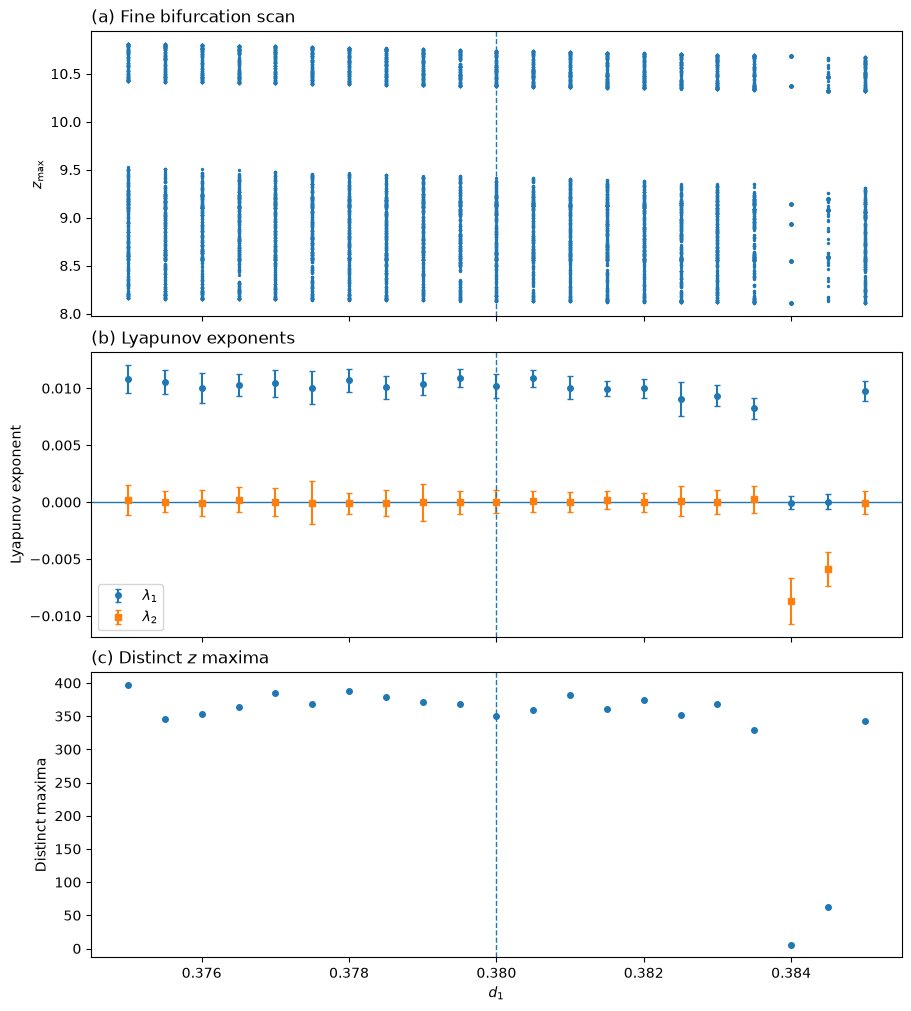

In [16]:
d1_values_038 = scan_results_038[:, 0]

lambda1_038 = scan_results_038[:, 1]
error1_038 = scan_results_038[:, 2]

lambda2_038 = scan_results_038[:, 3]
error2_038 = scan_results_038[:, 4]

distinct_038 = scan_results_038[:, 7]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True,
    constrained_layout=True
)


# (a) Bifurcation diagram

axes[0].scatter(
    scan_maxima_038[:, 0],
    scan_maxima_038[:, 1],
    s=2
)

axes[0].axvline(
    0.38,
    linestyle="--",
    linewidth=1
)

axes[0].set_ylabel(
    r"$z_{\max}$"
)

axes[0].set_title(
    "(a) Fine bifurcation scan",
    loc="left"
)


# (b) First and second Lyapunov exponents

axes[1].errorbar(
    d1_values_038,
    lambda1_038,
    yerr=error1_038,
    fmt="o",
    markersize=4,
    capsize=2,
    label=r"$\lambda_1$"
)

axes[1].errorbar(
    d1_values_038,
    lambda2_038,
    yerr=error2_038,
    fmt="s",
    markersize=4,
    capsize=2,
    label=r"$\lambda_2$"
)

axes[1].axhline(
    0.0,
    linewidth=1
)

axes[1].axvline(
    0.38,
    linestyle="--",
    linewidth=1
)

axes[1].set_ylabel(
    "Lyapunov exponent"
)

axes[1].set_title(
    "(b) Lyapunov exponents",
    loc="left"
)

axes[1].legend()


# (c) Number of distinct maxima

axes[2].plot(
    d1_values_038,
    distinct_038,
    "o",
    markersize=4
)

axes[2].axvline(
    0.38,
    linestyle="--",
    linewidth=1
)

axes[2].set_xlabel(
    r"$d_1$"
)

axes[2].set_ylabel(
    "Distinct maxima"
)

axes[2].set_title(
    r"(c) Distinct $z$ maxima",
    loc="left"
)


fig.savefig(
    "figures/hp_d1_scan_0375_0385.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_scan_0375_0385.pdf",
    bbox_inches="tight"
)

plt.show()

In [17]:
# Very fine scan around d1 = 0.45

d1_scan_045 = np.arange(
    0.4470,
    0.4530 + 0.00005,
    0.0001
)

d1_scan_045 = np.round(
    d1_scan_045,
    4
)

print("Number of d1 values:")
print(len(d1_scan_045))

Number of d1 values:
61


In [18]:
scan_results_045 = []
scan_maxima_045 = []

In [19]:
for i, d1_value in enumerate(d1_scan_045):

    parameters = np.array([
        a1,
        a2,
        b1,
        b2,
        d1_value,
        d2
    ])


    # Lyapunov spectrum

    block_exponents, final_state, _ = lyapunov_spectrum_blocks(
        parameters,
        initial_state,
        dt,
        transient_time=20000.0,
        alignment_time=5000.0,
        average_time=20000.0,
        renormalization_time=1.0,
        block_time=500.0
    )

    (
        spectrum,
        errors,
        _,
        _,
        _,
        stationary
    ) = spectrum_statistics(block_exponents)


    # Successive maxima of z

    maxima, _ = z_maxima(
        parameters,
        initial_state,
        dt,
        transient_time=20000.0,
        record_time=20000.0,
        max_peaks=500
    )

    distinct_maxima = len(
        np.unique(
            np.round(maxima, 3)
        )
    )


    scan_results_045.append([
        d1_value,
        spectrum[0],
        errors[0],
        spectrum[1],
        errors[1],
        spectrum[2],
        errors[2],
        distinct_maxima,
        stationary[0],
        stationary[1],
        stationary[2],
        final_state[0],
        final_state[1],
        final_state[2]
    ])


    for z_peak in maxima:

        scan_maxima_045.append([
            d1_value,
            z_peak
        ])


    print(
        f"[{i + 1:02d}/{len(d1_scan_045)}] "
        f"d1 = {d1_value:.4f}   "
        f"lambda1 = {spectrum[0]:.6f}   "
        f"lambda2 = {spectrum[1]:.6f}   "
        f"distinct maxima = {distinct_maxima}",
        flush=True
    )

[01/61] d1 = 0.4470   lambda1 = 0.003207   lambda2 = -0.000018   distinct maxima = 201
[02/61] d1 = 0.4471   lambda1 = 0.003040   lambda2 = 0.000088   distinct maxima = 189
[03/61] d1 = 0.4472   lambda1 = 0.003187   lambda2 = 0.000105   distinct maxima = 196
[04/61] d1 = 0.4473   lambda1 = 0.002641   lambda2 = 0.000084   distinct maxima = 150
[05/61] d1 = 0.4474   lambda1 = 0.002419   lambda2 = -0.000009   distinct maxima = 178
[06/61] d1 = 0.4475   lambda1 = 0.003057   lambda2 = 0.000086   distinct maxima = 170
[07/61] d1 = 0.4476   lambda1 = 0.003175   lambda2 = 0.000072   distinct maxima = 206
[08/61] d1 = 0.4477   lambda1 = 0.003068   lambda2 = 0.000172   distinct maxima = 191
[09/61] d1 = 0.4478   lambda1 = 0.003165   lambda2 = 0.000187   distinct maxima = 191
[10/61] d1 = 0.4479   lambda1 = 0.002724   lambda2 = -0.000031   distinct maxima = 184
[11/61] d1 = 0.4480   lambda1 = 0.003007   lambda2 = 0.000165   distinct maxima = 193
[12/61] d1 = 0.4481   lambda1 = 0.003326   lambda2 

In [20]:
scan_results_045 = np.array(
    scan_results_045,
    dtype=float
)

scan_maxima_045 = np.array(
    scan_maxima_045,
    dtype=float
)

print(scan_results_045.shape)
print(scan_maxima_045.shape)

(61, 14)
(16987, 2)


In [21]:
scan_header_045 = """Very fine Hastings-Powell scan around d1 = 0.45
d1 range = 0.4470 to 0.4530
d1 step = 0.0001

a1 = 5.0
a2 = 0.1
b1 = 3.0
b2 = 2.0
d2 = 0.01

dt = 0.01
transient_time = 20000
alignment_time = 5000
average_time = 20000
renormalization_time = 1
block_time = 500
initial_state = [1.0, 1.0, 1.0]

errors = half-width of approximate 95% Student interval

columns:
d1,lambda1,error1,lambda2,error2,lambda3,error3,distinct_maxima,
stationary1,stationary2,stationary3,final_x,final_y,final_z
"""

np.savetxt(
    "data/hp_d1_scan_0447_0453.csv",
    scan_results_045,
    delimiter=",",
    header=scan_header_045,
    comments="# "
)

print("Saved: data/hp_d1_scan_0447_0453.csv")

Saved: data/hp_d1_scan_0447_0453.csv


In [22]:
maxima_header_045 = """Successive maxima of z for the very fine d1 scan around d1 = 0.45
d1 range = 0.4470 to 0.4530
d1 step = 0.0001

dt = 0.01
transient_time = 20000
record_time = 20000
initial_state = [1.0, 1.0, 1.0]

columns: d1,z_max
"""

np.savetxt(
    "data/hp_d1_scan_0447_0453_maxima.csv",
    scan_maxima_045,
    delimiter=",",
    header=maxima_header_045,
    comments="# "
)

print("Saved: data/hp_d1_scan_0447_0453_maxima.csv")

Saved: data/hp_d1_scan_0447_0453_maxima.csv


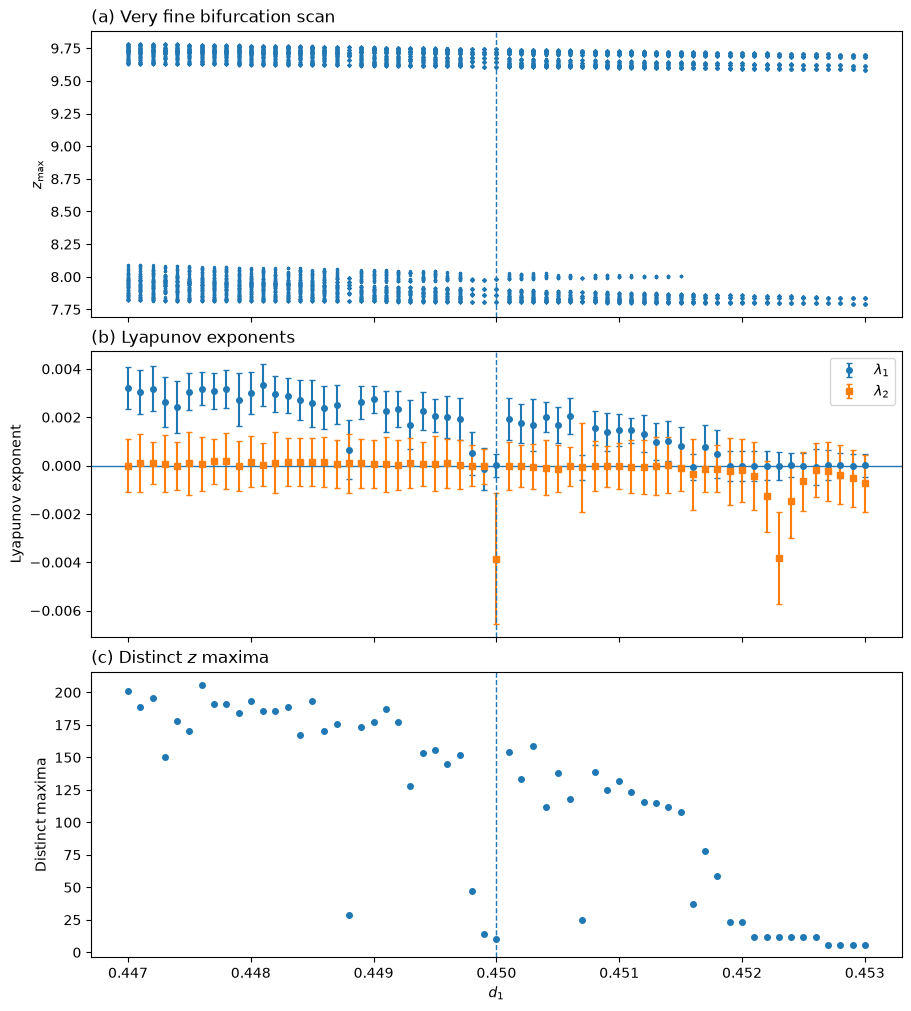

In [23]:
d1_values_045 = scan_results_045[:, 0]

lambda1_045 = scan_results_045[:, 1]
error1_045 = scan_results_045[:, 2]

lambda2_045 = scan_results_045[:, 3]
error2_045 = scan_results_045[:, 4]

distinct_045 = scan_results_045[:, 7]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True,
    constrained_layout=True
)


# (a) Bifurcation diagram

axes[0].scatter(
    scan_maxima_045[:, 0],
    scan_maxima_045[:, 1],
    s=2
)

axes[0].axvline(
    0.45,
    linestyle="--",
    linewidth=1
)

axes[0].set_ylabel(
    r"$z_{\max}$"
)

axes[0].set_title(
    "(a) Very fine bifurcation scan",
    loc="left"
)


# (b) First and second Lyapunov exponents

axes[1].errorbar(
    d1_values_045,
    lambda1_045,
    yerr=error1_045,
    fmt="o",
    markersize=4,
    capsize=2,
    label=r"$\lambda_1$"
)

axes[1].errorbar(
    d1_values_045,
    lambda2_045,
    yerr=error2_045,
    fmt="s",
    markersize=4,
    capsize=2,
    label=r"$\lambda_2$"
)

axes[1].axhline(
    0.0,
    linewidth=1
)

axes[1].axvline(
    0.45,
    linestyle="--",
    linewidth=1
)

axes[1].set_ylabel(
    "Lyapunov exponent"
)

axes[1].set_title(
    "(b) Lyapunov exponents",
    loc="left"
)

axes[1].legend()


# (c) Number of distinct maxima

axes[2].plot(
    d1_values_045,
    distinct_045,
    "o",
    markersize=4
)

axes[2].axvline(
    0.45,
    linestyle="--",
    linewidth=1
)

axes[2].set_xlabel(
    r"$d_1$"
)

axes[2].set_ylabel(
    "Distinct maxima"
)

axes[2].set_title(
    r"(c) Distinct $z$ maxima",
    loc="left"
)


fig.savefig(
    "figures/hp_d1_scan_0447_0453.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "figures/hp_d1_scan_0447_0453.pdf",
    bbox_inches="tight"
)

plt.show()